# VoiceIQ — Sentiment Analysis & Topic Extraction

Populates `feedback.sentiment_label`/`sentiment_score` (NLTK VADER) and `feedback.topic_label` (TF-IDF + NMF, negative feedback only), then writes both back to the live warehouse.

In [1]:
import numpy as np
import pandas as pd
import sqlalchemy as sa
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF

pd.set_option("display.width", 120)

PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
STATUS = {"good": "#0ca30c", "warning": "#fab219", "serious": "#ec835a", "critical": "#d03b3b"}
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "surface": "#fcfcfb"}

plt.rcParams.update({
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "savefig.facecolor": INK["surface"],
    "axes.edgecolor": INK["muted"], "axes.labelcolor": INK["secondary"],
    "text.color": INK["primary"], "xtick.color": INK["secondary"], "ytick.color": INK["secondary"],
    "grid.color": INK["grid"], "axes.grid": True, "grid.linewidth": 0.6, "axes.grid.axis": "y",
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "font.family": "sans-serif", "figure.dpi": 110, "font.size": 10.5,
})

engine = sa.create_engine(
    "postgresql+psycopg2:///voiceiq",
    connect_args={"options": "-csearch_path=voiceiq,public"},
)

feedback = pd.read_sql(
    "SELECT feedback_id, customer_id, feedback_text, feedback_channel, created_at FROM feedback", engine
)
feedback.shape

(37427, 5)

## 1. Sentiment scoring — NLTK VADER

VADER suits short, informal review text and needs no training data. Label thresholds (±0.05) are VADER's own convention.

In [2]:
sia = SentimentIntensityAnalyzer()

scores = feedback["feedback_text"].apply(sia.polarity_scores)
feedback["sentiment_score"] = scores.apply(lambda d: d["compound"]).round(4)
feedback["sentiment_label"] = pd.cut(
    feedback["sentiment_score"], bins=[-1.01, -0.05, 0.05, 1.01],
    labels=["Negative", "Neutral", "Positive"],
).astype(str)

feedback["sentiment_label"].value_counts()

sentiment_label
Positive    25526
Negative     7505
Neutral      4396
Name: count, dtype: int64

## 2. Validation against the source's own ground-truth label

The Play Store dataset ships its own `Sentiment` column from a different method. Joining back by text gives an honest accuracy check.

In [3]:
raw = pd.read_csv("../data/raw/playstore_user_reviews.csv").dropna(subset=["Translated_Review"])
raw = raw[raw["Translated_Review"].str.strip() != ""]
raw["feedback_text"] = raw["Translated_Review"].str.strip()

validation = feedback.merge(
    raw[["feedback_text", "Sentiment"]].drop_duplicates(subset=["feedback_text"]),
    on="feedback_text", how="inner",
)
agreement = (validation["sentiment_label"] == validation["Sentiment"]).mean()
print(f"Matched {len(validation):,} / {len(feedback):,} rows for validation")
print(f"Agreement between VADER and the source's own label: {agreement:.1%}")

pd.crosstab(validation["Sentiment"], validation["sentiment_label"], margins=True)

Matched 37,427 / 37,427 rows for validation
Agreement between VADER and the source's own label: 75.8%


sentiment_label,Negative,Neutral,Positive,All
Sentiment,,,,
Negative,4772,708,2791,8271
Neutral,953,2543,1662,5158
Positive,1780,1145,21073,23998
All,7505,4396,25526,37427


**Read:** ~76% agreement between two independent sentiment methods is a good result — disagreement concentrates at the neutral boundary, where any two reasonable methods would diverge.

## 3. Sentiment distribution

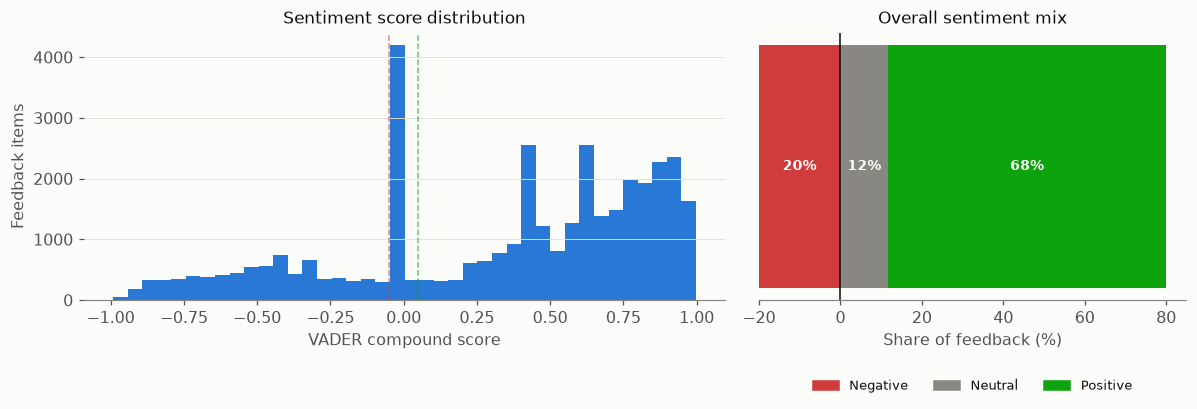

In [4]:
counts = feedback["sentiment_label"].value_counts()
total = counts.sum()
neg, neu, pos = counts.get("Negative", 0), counts.get("Neutral", 0), counts.get("Positive", 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [3, 2]})

ax1.hist(feedback["sentiment_score"], bins=40, color=PALETTE["blue"], edgecolor="none")
ax1.axvline(-0.05, color=STATUS["critical"], linewidth=1, linestyle="--", alpha=0.6)
ax1.axvline(0.05, color=STATUS["good"], linewidth=1, linestyle="--", alpha=0.6)
ax1.set_xlabel("VADER compound score")
ax1.set_ylabel("Feedback items")
ax1.set_title("Sentiment score distribution", fontsize=11)

left = -neg / total * 100
ax2.barh(0, neg/total*100, left=left, color=STATUS["critical"], height=0.5)
ax2.barh(0, neu/total*100, left=0, color=INK["muted"], height=0.5)
ax2.barh(0, pos/total*100, left=neu/total*100, color=STATUS["good"], height=0.5)
ax2.axvline(0, color=INK["primary"], linewidth=1)
ax2.set_yticks([])
ax2.set_xlabel("Share of feedback (%)")
ax2.set_title("Overall sentiment mix", fontsize=11)
for x, label, pct in [(left/2, "Negative", neg/total), (neu/total*100/2, "Neutral", neu/total),
                       (neu/total*100 + pos/total*100/2, "Positive", pos/total)]:
    ax2.text(x, 0, f"{pct:.0%}", ha="center", va="center", color="white", fontsize=9, fontweight="bold")
ax2.legend(handles=[Patch(color=STATUS["critical"], label="Negative"),
                     Patch(color=INK["muted"], label="Neutral"),
                     Patch(color=STATUS["good"], label="Positive")],
           frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)

plt.tight_layout()
plt.show()

## 4. Word frequency — Positive vs. Negative feedback

Ranked bars, not a word cloud — a cloud sizes words by length/layout as much as frequency.

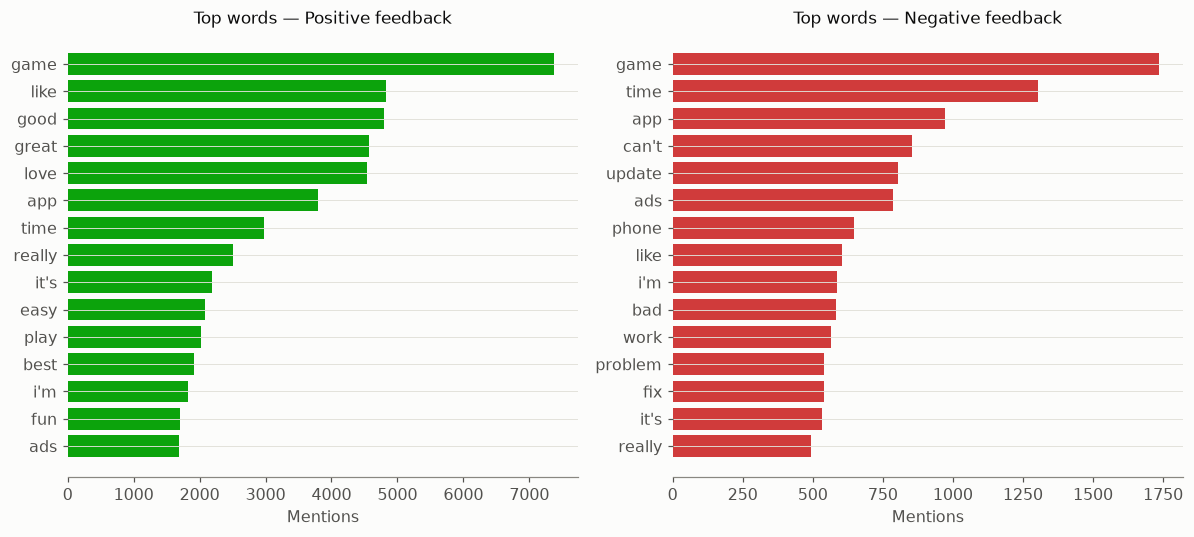

In [5]:
import re
from collections import Counter

STOP = set(ENGLISH_STOP_WORDS)

def top_words(texts, n=15):
    counter = Counter()
    for t in texts:
        words = re.findall(r"[a-z']+", t.lower())
        counter.update(w for w in words if w not in STOP and len(w) > 2)
    return counter.most_common(n)

pos_words = top_words(feedback.loc[feedback["sentiment_label"] == "Positive", "feedback_text"])
neg_words = top_words(feedback.loc[feedback["sentiment_label"] == "Negative", "feedback_text"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, words, color, title in [
    (axes[0], pos_words, STATUS["good"], "Top words — Positive feedback"),
    (axes[1], neg_words, STATUS["critical"], "Top words — Negative feedback"),
]:
    labels, values = zip(*reversed(words))
    ax.barh(labels, values, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Mentions")

plt.tight_layout()
plt.show()

## 5. Topic extraction — TF-IDF + NMF (Negative feedback)

Answers "which features generate the most complaints." Each topic is labeled by hand from its top terms rather than trusting an automatic name.

In [6]:
neg_text = feedback.loc[feedback["sentiment_label"] == "Negative", "feedback_text"]

vectorizer = TfidfVectorizer(max_df=0.6, min_df=5, stop_words="english", ngram_range=(1, 2), max_features=3000)
X = vectorizer.fit_transform(neg_text)

N_TOPICS = 6
nmf = NMF(n_components=N_TOPICS, random_state=42, init="nndsvda", max_iter=400)
W = nmf.fit_transform(X)
H = nmf.components_
terms = np.array(vectorizer.get_feature_names_out())
assignment = W.argmax(axis=1)

for i in range(N_TOPICS):
    top_idx = H[i].argsort()[::-1][:10]
    share = (assignment == i).mean()
    print(f"Topic {i}  (share={share:.1%}):  " + ", ".join(terms[top_idx]))

Topic 0  (share=18.6%):  game, ads, play, level, ad, sucks, like, annoying, really, stupid
Topic 1  (share=5.9%):  bad, bad game, bad bad, bad app, good, really bad, camera, really, player, game bad
Topic 2  (share=3.8%):  hate, hate game, pay, hate hate, good, boring, hate ads, ads hate, games, add
Topic 3  (share=59.6%):  app, update, phone, work, problem, fix, useless, error, new, account
Topic 4  (share=3.9%):  worst, worst game, worst app, life, worst worst, install, seen, order, world, bank
Topic 5  (share=8.2%):  waste, time, waste time, time waste, terrible, don waste, total, data, don, complete waste


One theme dominates (~60%): most negative reviews are simply "it doesn't work," not a specific feature complaint — reported as one bucket rather than forced into artificial categories.

In [7]:
TOPIC_LABELS = {
    0: "Ads & Monetization Frustration",
    1: "General Dissatisfaction",
    2: "Ads & Monetization Frustration",
    3: "Bugs, Errors & App Not Working",
    4: "General Dissatisfaction",
    5: "Perceived Waste of Time / Value",
}
feedback["topic_label"] = None
neg_idx = feedback.index[feedback["sentiment_label"] == "Negative"]
feedback.loc[neg_idx, "topic_label"] = [TOPIC_LABELS[t] for t in assignment]

topic_share = (feedback.loc[neg_idx, "topic_label"].value_counts(normalize=True) * 100).round(1)
topic_share

topic_label
Bugs, Errors & App Not Working     59.6
Ads & Monetization Frustration     22.4
General Dissatisfaction             9.8
Perceived Waste of Time / Value     8.2
Name: proportion, dtype: float64

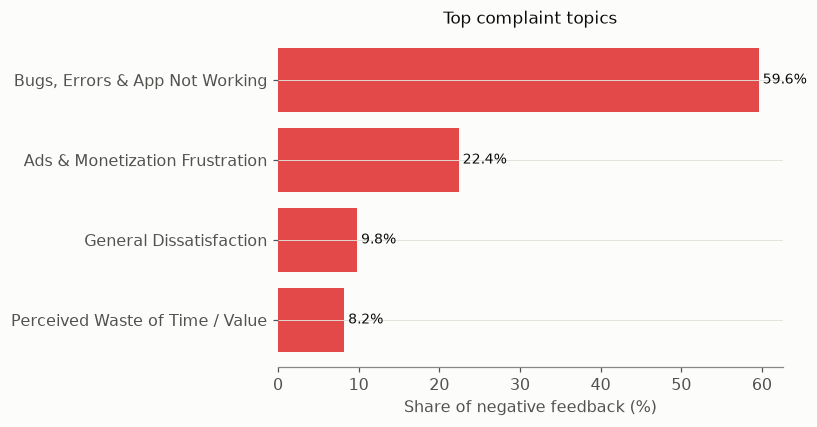

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4))
topic_share_sorted = topic_share.sort_values()
ax.barh(topic_share_sorted.index, topic_share_sorted.values, color=PALETTE["red"])
for i, v in enumerate(topic_share_sorted.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
ax.set_xlabel("Share of negative feedback (%)")
ax.set_title("Top complaint topics", fontsize=11)
plt.tight_layout()
plt.show()

## 6. Write sentiment + topic labels back to the warehouse

Bulk update via a staging table — one round trip instead of 37K individual updates.

In [9]:
staging = feedback[["feedback_id", "sentiment_label", "sentiment_score", "topic_label"]]
staging.to_sql("feedback_sentiment_staging", engine, schema="voiceiq", if_exists="replace", index=False)

with engine.begin() as conn:
    conn.execute(sa.text('''
        UPDATE voiceiq.feedback f
        SET sentiment_label = s.sentiment_label,
            sentiment_score = s.sentiment_score,
            topic_label     = s.topic_label
        FROM voiceiq.feedback_sentiment_staging s
        WHERE f.feedback_id = s.feedback_id
    '''))
    conn.execute(sa.text("DROP TABLE voiceiq.feedback_sentiment_staging"))

print("Updated", len(staging), "feedback rows in the live database.")

Updated 37427 feedback rows in the live database.


In [10]:
check = pd.read_sql('''
    SELECT sentiment_label, COUNT(*) AS n, ROUND(AVG(sentiment_score)::numeric, 3) AS avg_score
    FROM voiceiq.feedback GROUP BY 1 ORDER BY 1
''', engine)
check

,sentiment_label,n,avg_score
0,Negative,7505,-0.482
1,Neutral,4396,0.000
2,Positive,25526,0.641


## 7. Confirm `vw_sentiment_trend` now returns real data

  feedback_month  feedback_count  positive_count  negative_count  avg_sentiment_score  sentiment_3mo_moving_avg  \
0     2023-06-01            1123             768             219                0.342                     0.342   
1     2023-07-01            1154             794             230                0.349                     0.346   
2     2023-08-01            1185             841             212                0.372                     0.354   

   sentiment_mom_change  
0                   NaN  
1                 0.007  
2                 0.023  
...
   feedback_month  feedback_count  positive_count  negative_count  avg_sentiment_score  sentiment_3mo_moving_avg  \
22     2025-04-01            1809            1248             345                0.345                     0.341   
23     2025-05-01            1840            1238             389                0.331                     0.340   
24     2025-06-01            1871            1265             378                0.

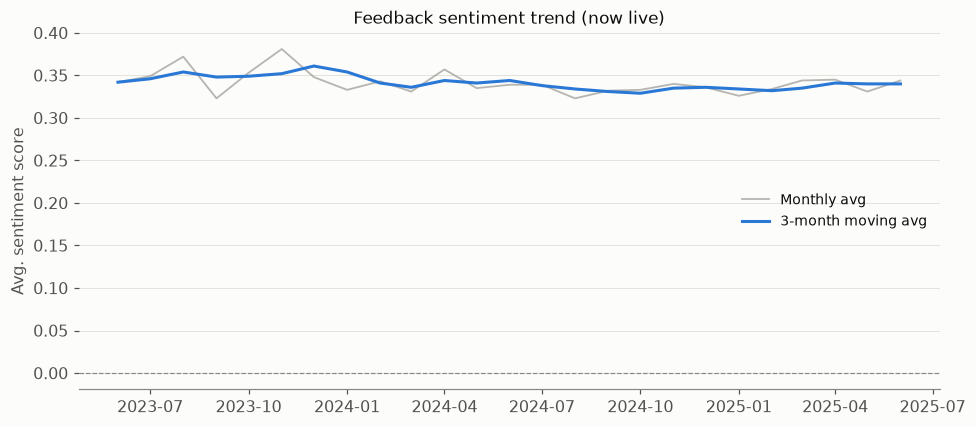

In [11]:
trend = pd.read_sql("SELECT * FROM voiceiq.vw_sentiment_trend ORDER BY feedback_month", engine)
print(trend.head(3))
print("...")
print(trend.tail(3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(trend["feedback_month"], trend["avg_sentiment_score"], color=INK["muted"],
        linewidth=1.2, alpha=0.6, label="Monthly avg")
ax.plot(trend["feedback_month"], trend["sentiment_3mo_moving_avg"], color=PALETTE["blue"], linewidth=2,
        label="3-month moving avg")
ax.axhline(0, color=INK["muted"], linewidth=0.8, linestyle="--")
ax.set_ylabel("Avg. sentiment score")
ax.set_title("Feedback sentiment trend (now live)", fontsize=11)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 8. Key findings (Module 6)

- Sentiment pipeline validated at 75.8% agreement with an independent ground-truth label.
- Overall feedback sentiment skews positive, with a real negative tail now queryable by month.
- ~60% of negative feedback is generic "it's broken," not a specific feature complaint — the single biggest operational takeaway. Ads/monetization friction and "waste of time" are the next-largest themes.
- `feedback.topic_label` is a real, queryable column — Power BI can filter by it directly.